In [1]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from sklearn.model_selection import KFold

In [2]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed"

In [3]:
data = pd.read_parquet(f"{DATASET_DIR}/csecicids2018.parquet")

In [4]:
label_mapping = {
    'Benign': 'Benign',
    'Bot': 'Botnet',
    'FTP-BruteForce': 'Brute Force',
    'SSH-Bruteforce': 'Brute Force',
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDOS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-SlowHTTPTest': 'DoS',
    'DoS attacks-Hulk': 'DoS',
    'Infilteration': 'Infiltration',
    'Brute Force -Web': 'Brute Force',
    'Brute Force -XSS': 'Brute Force',
    'SQL Injection': 'Infiltration'  # Assuming SQL Injection is part of Infiltration
}

data["Label"] = data["Label"].map(label_mapping)

In [5]:
data["Label"].value_counts()

Label
Benign          5329008
DDoS             775955
DoS              196568
Botnet           144535
Infiltration     118568
Brute Force       94898
Name: count, dtype: int64

In [6]:
sampled_data = data.groupby("Label").sample(5000, random_state=42)
sampled_data.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
1119705,6,4959888,4,4,97,232.0,97,0,24.250000,48.500000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2975672,6,4776917,11,14,1623,4513.0,661,0,147.545456,189.151978,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
6489183,6,1247683,7,5,364,582.0,103,0,52.000000,49.217205,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2675390,6,1098,5,2,935,316.0,935,0,187.000000,418.144714,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
5559062,6,2160480,9,7,1148,1581.0,677,0,127.555557,218.691055,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [8]:
sampled_index = sampled_data.index

In [ ]:
import pickle
import os
from PIL import Image

# store images and labels in a dataframe


images = []
labels = []

images_dir = f"{DATASET_DIR}/images"

with open(f"{DATASET_DIR}/labels.pkl", "rb") as f:
    all_labels = pickle.load(f)

for index in sampled_index:
    # images are grayscale, with mode L
    image_path = f"{images_dir}/image_{index}.png"
    images.append(image_path)
    labels.append(all_labels[index])

image_df = pd.DataFrame({
    "Image": images,
    "Label": labels
})

In [10]:
image_df.head()

,Image,Label
0,../data/processed/images/image_1119705.png,Benign
1,../data/processed/images/image_2975672.png,Benign
2,../data/processed/images/image_6489183.png,Benign
3,../data/processed/images/image_2675390.png,Benign
4,../data/processed/images/image_5559062.png,Benign


In [11]:
def clean_image_path(image_path):
    return os.path.basename(image_path)


image_df["Image"] = image_df["Image"].apply(clean_image_path)
image_df.head()

,Image,Label
0,image_1119705.png,Benign
1,image_2975672.png,Benign
2,image_6489183.png,Benign
3,image_2675390.png,Benign
4,image_5559062.png,Benign


In [12]:
image_df["Label"].value_counts()

Label
Malicious    25000
Benign        5000
Name: count, dtype: int64

In [13]:
from sklearn.preprocessing import LabelEncoder

class CustomDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.dataframe.iloc[idx]["Image"])
        with Image.open(image_path) as img:
            if self.transform:
                img = self.transform(img)
            label = torch.as_tensor(self.dataframe.iloc[idx]["Label"], dtype=torch.long)
            return img, label

In [14]:
LE = LabelEncoder()
image_df_encoded = image_df.copy()
image_df_encoded["Label"] = LE.fit_transform(image_df_encoded["Label"])

image_df_encoded["Label"].value_counts()


Label
1    25000
0     5000
Name: count, dtype: int64

In [15]:
image_dir = f"{DATASET_DIR}/sampled_images"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

dataset = CustomDataset(image_df_encoded, image_dir, transform=transform)

In [16]:
BATCH_SIZE = 40
train_dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [41]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc_bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # print(x.shape)

        x = torch.flatten(x, 1)

        # print(x.shape)

        x = F.relu(self.fc_bn1(self.fc1(x)))
        x = self.fc2(x)
        return self.sigmoid(x)


In [17]:
class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            # First block: 32x32 -> 16x16
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),
            
            # Second block: 16x16 -> 8x8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

        )
        
        # Binary classifier
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 *8 , 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
            # nn.Sigmoid()  # Binary classification output
        )
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [60]:
def plot_metrics(metrics, num_folds):
    plt.figure(figsize=(15, 5))
    
    # Plot losses
    plt.subplot(1, 2, 1)
    for fold in range(num_folds):
        plt.plot(metrics['train_losses'][fold], label=f'Fold {fold+1} Train')
        plt.plot(metrics['val_losses'][fold], label=f'Fold {fold+1} Val')
    plt.title('Loss vs Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot accuracies
    plt.subplot(1, 2, 2)
    for fold in range(num_folds):
        plt.plot(metrics['train_accuracies'][fold], label=f'Fold {fold+1} Train')
        plt.plot(metrics['val_accuracies'][fold], label=f'Fold {fold+1} Val')
    plt.title('Accuracy vs Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
def train_model_with_kfold(model_class, dataset, num_folds=5, num_epochs=50, batch_size=40, lr=0.001, patience=5, device='cuda', pos_weight=None, model_path=""):
    # Initialize K-Fold
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)
    
    # Store metrics for each fold
    all_folds_metrics = {
        'train_losses': [],
        'val_losses': [],
        'train_accuracies': [],
        'val_accuracies': []
    }
    
    for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
        print(f'FOLD {fold+1}/{num_folds}')
        print('-' * 50)
        
        # Create data loaders for this fold
        train_dataset = Subset(dataset, train_ids)
        val_dataset = Subset(dataset, val_ids)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # Initialize model, criterion, optimizer for this fold
        model = model_class().to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.1, patience=patience
        )
        
        # Training loop for this fold
        best_val_loss = float('inf')
        early_stop_counter = 0
        fold_metrics = {
            'train_losses': [],
            'val_losses': [],
            'train_accuracies': [],
            'val_accuracies': []
        }
        
        for epoch in range(num_epochs):
            # Training phase
            model.train()
            train_loss = 0
            train_correct = 0
            train_total = 0
            
            for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
                inputs, labels = inputs.to(device), labels.float().to(device)
                
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels.view(-1, 1))
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                predicted = (outputs > 0.5).float()
                train_total += labels.size(0)
                train_correct += (predicted.view(-1) == labels).sum().item()
            
            train_loss = train_loss / len(train_loader)
            train_acc = 100 * train_correct / train_total
            
            # Validation phase
            model.eval()
            val_loss = 0
            val_correct = 0
            val_total = 0
            
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels.float().view(-1, 1))
                    val_loss += loss.item()
                    predicted = (outputs > 0.5).float()
                    val_total += labels.size(0)
                    val_correct += (predicted.view(-1) == labels).sum().item()
            
            val_loss = val_loss / len(val_loader)
            val_acc = 100 * val_correct / val_total
            
            # Store metrics
            fold_metrics['train_losses'].append(train_loss)
            fold_metrics['val_losses'].append(val_loss)
            fold_metrics['train_accuracies'].append(train_acc)
            fold_metrics['val_accuracies'].append(val_acc)
            
            print(f'\nEpoch {epoch+1}/{num_epochs}:')
            print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
            print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        
            # Update learning rate
            scheduler.step(val_loss)
            
            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), f'{model_path}cnn_best_model_fold_{fold+1}.pth')
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f'Early stopping triggered at epoch {epoch+1}')
                    break
            
        all_folds_metrics['train_losses'].append(fold_metrics['train_losses'])
        all_folds_metrics['val_losses'].append(fold_metrics['val_losses'])
        all_folds_metrics['train_accuracies'].append(fold_metrics['train_accuracies'])
        all_folds_metrics['val_accuracies'].append(fold_metrics['val_accuracies'])
    
    # Plot metrics for all folds
    plot_metrics(all_folds_metrics, num_folds)
    
    return all_folds_metrics


In [76]:
def calculate_pos_weights(class_counts):
    pos_weights = np.ones_like(class_counts)
    neg_counts = [len(data)-pos_count for pos_count in class_counts]
    for cdx, pos_count, neg_count in enumerate(zip(class_counts,  neg_counts)):
      pos_weights[cdx] = neg_count / (pos_count + 1e-5)

    return torch.as_tensor(pos_weights, dtype=torch.float).to(device)

tensor([5.], device='cuda:0')
FOLD 1/5
--------------------------------------------------


Epoch 1/50:   0%|          | 0/600 [00:00<?, ?it/s]

Epoch 1/50: 100%|██████████| 600/600 [00:20<00:00, 29.48it/s]



Epoch 1/50:
Train Loss: 0.5080 | Train Acc: 86.04%
Val Loss: 0.3662 | Val Acc: 90.38%


Epoch 2/50: 100%|██████████| 600/600 [00:20<00:00, 29.35it/s]


...


Epoch 33/50:
Train Loss: 0.2858 | Train Acc: 92.23%
Val Loss: 0.3143 | Val Acc: 91.38%


Epoch 34/50: 100%|██████████| 600/600 [00:22<00:00, 26.21it/s]



Epoch 34/50:
Train Loss: 0.2841 | Train Acc: 92.38%
Val Loss: 0.3118 | Val Acc: 91.27%


Epoch 35/50: 100%|██████████| 600/600 [00:23<00:00, 25.93it/s]



Epoch 35/50:
Train Loss: 0.2812 | Train Acc: 92.57%
Val Loss: 0.3166 | Val Acc: 91.32%
Early stopping triggered at epoch 35


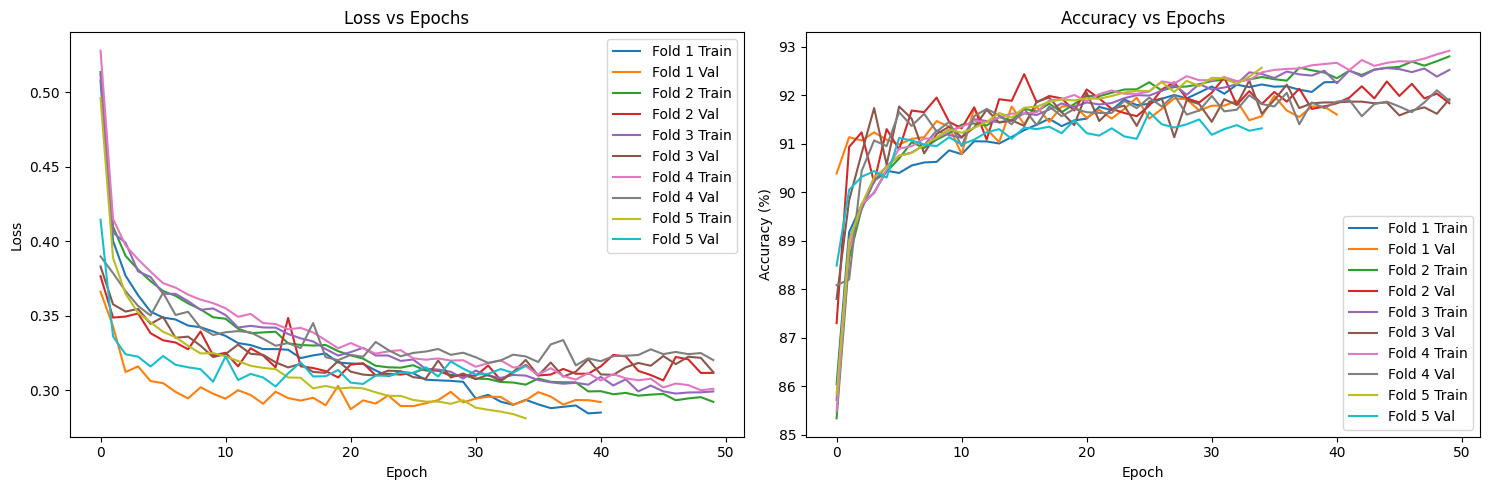

In [77]:
benign_count = image_df_encoded["Label"].value_counts()[0]
malicious_count = image_df_encoded.shape[0] - benign_count
total_count = image_df_encoded.shape[0]

pos_weight = torch.tensor([malicious_count / benign_count], dtype=torch.float32).to(device)

print(pos_weight)


metrics = train_model_with_kfold(BinaryCNN, dataset, num_folds=5, num_epochs=50, batch_size=40, lr=0.001, patience=20, device=device, pos_weight=pos_weight, model_path="../models/checkpoints/")

In [ ]:
def train_Kfolds(model_class, dataset, k=5, epochs=10, batch_size=40, lr=0.001, patience=3, device="cuda", save_path="../models/checkpoints/cnn_best_model.pth"):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    dataset_list = list(dataset)

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset_list)):
        print(f"Fold {fold + 1}")
        train_dataset = Subset(dataset, train_idx)
        val_dataset = Subset(dataset, val_idx)

        train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = model_class().to(device)
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=patience)

        best_val_loss = np.inf
        early_stopping_counter = 0

        for epoch in range(epochs):
            model.train()
            train_loss, correct_train = 0, 0

            for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs} Training", leave=False):
                images, labels = images.to(device), labels.float().to(device)
                labels = labels.view(-1, 1)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()

                optimizer.step()

                train_loss += loss.item()
                correct_train += ((outputs > 0.5).float() == labels).sum().item()

            model.eval()
            val_loss, correct_val = 0, 0

            with torch.no_grad():
                for images, labels in tqdm(val_dataloader, desc=f"Epoch {epoch + 1}/{epochs} Validation", leave=False):
                    images, labels = images.to(device), labels.float().to(device)
                    labels = labels.view(-1, 1)

                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item()
                    correct_val += ((outputs > 0.5).float() == labels).sum().item()
            
            avg_train_loss = train_loss / len(train_dataloader)
            avg_val_loss = val_loss / len(val_dataloader)
            train_accuracy = correct_train / len(train_dataset)
            val_accuracy = correct_val / len(val_dataset)

            train_losses.append(avg_train_loss)
            val_losses.append(avg_val_loss)
            train_accuracies.append(train_accuracy)
            val_accuracies.append(val_accuracy)

            print(f"Epoch {epoch + 1}/{epochs} Loss: {avg_train_loss:.4f} Accuracy: {train_accuracy:.4f} Validation Loss: {avg_val_loss:.4f} Accuracy: {val_accuracy:.4f}")

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                early_stopping_counter = 0
                torch.save(model.state_dict(), save_path)
                print(f"Saving best model with validation loss {best_val_loss:.4f}")
            else:
                early_stopping_counter += 1
                if early_stopping_counter >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

            scheduler.step(avg_val_loss)

    return train_losses, val_losses, train_accuracies, val_accuracies


In [82]:
# calculate which fold has the best validation accuracy and least validation loss
best_fold = np.argmax([np.max(metrics['val_accuracies'][i]) for i in range(5)])

print(f"Best fold: {best_fold + 1}")

Best fold: 2
